In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
def ErrorEstimate(x, y, S):
    x_subset = x[S]
    model = LogisticRegression(penalty=None, max_iter=2000, solver='lbfgs')
    accuracy = cross_val_score(model, x_subset, y, cv=5, scoring='accuracy')
    return 1 - np.mean(accuracy)

In [3]:
def stepwise_forward_selection(x_train, y_train, max_features):
    S = []
    all_features = list(x_train.columns)
    cv_errors_by_k = []

    # Repeat k times up to max_features
    for k in range(max_features):
        best_error = float('inf')
        best_feature = None

        # Select feature f with the smallest error estimate
        for f in all_features:
            if f not in S:
                current_f = S + [f]
                error = ErrorEstimate(x_train, y_train, current_f)

                # Update best feature if current error is lower
                if error < best_error:
                    best_error = error
                    best_feature = f

        # Add the best feature found in this iteration to the selected set
        if best_feature:
            S.append(best_feature)
            cv_errors_by_k.append(best_error)
        else:
            break

    return S, cv_errors_by_k

In [4]:
data = pd.read_csv('../datasets/heart.csv', header=0)

target_col_name = data.columns[-1]
X = data.drop(columns=[target_col_name])
y = data[target_col_name]

feature_names = X.columns
total_features = len(feature_names)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=feature_names)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=feature_names)

In [5]:
selected_features_ordered, cv_errors = stepwise_forward_selection(x_train_scaled_df, y_train, total_features)
print(f"\nFinal ordered features: {selected_features_ordered}")


Final ordered features: ['cp', 'oldpeak', 'thal', 'thalach', 'ca', 'sex', 'fbs', 'slope', 'trestbps', 'restecg', 'chol', 'age', 'exang']


In [6]:
test_errors = []
for k in range(1, total_features + 1):
    k_features = selected_features_ordered[:k]

    x_train_subset = x_train_scaled_df[k_features]
    x_test_subset = x_test_scaled_df[k_features]

    model = LogisticRegression(penalty=None, max_iter=2000, solver='lbfgs')
    model.fit(x_train_subset, y_train)
    test_errors.append(1 - model.score(x_test_subset, y_test))

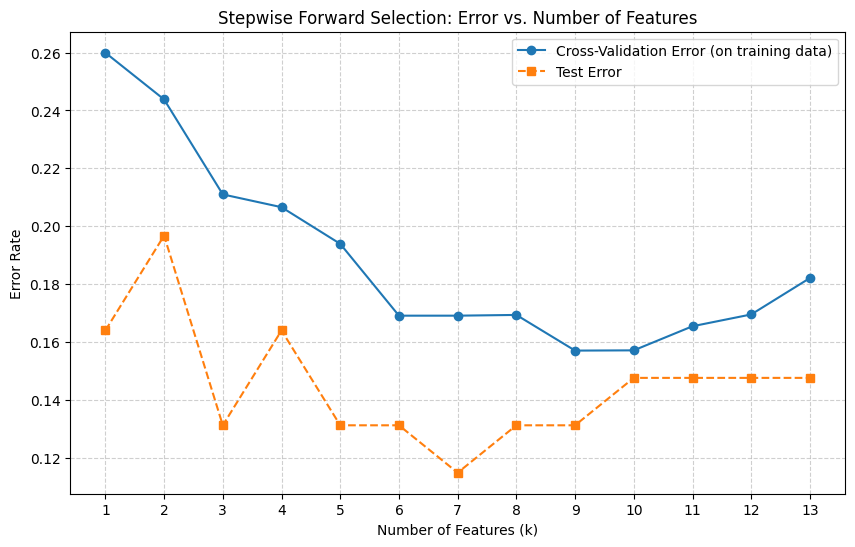

In [7]:
plt.figure(figsize=(10, 6))
k_values = range(1, total_features + 1)
plt.plot(k_values, cv_errors, marker='o', linestyle='-', label='Cross-Validation Error (on training data)')
plt.plot(k_values, test_errors, marker='s', linestyle='--', label='Test Error')
plt.title('Stepwise Forward Selection: Error vs. Number of Features')
plt.xlabel('Number of Features (k)')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
def plot_decision_boundary(X, y, model, feature_names):
    """
    Plots the decision boundary for a 2-feature logistic regression model.
    """
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    
    # Plot the data points
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.coolwarm)
    
    plt.title('Decision Boundary for k=2')
    plt.xlabel(f"Feature: {feature_names[0]}")
    plt.ylabel(f"Feature: {feature_names[1]}")
    plt.show()


--- Part (c) ---
The two features chosen for k=2 are: cp and oldpeak
Plotting decision boundary for k=2...


/opt/anaconda3/envs/cse151a/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


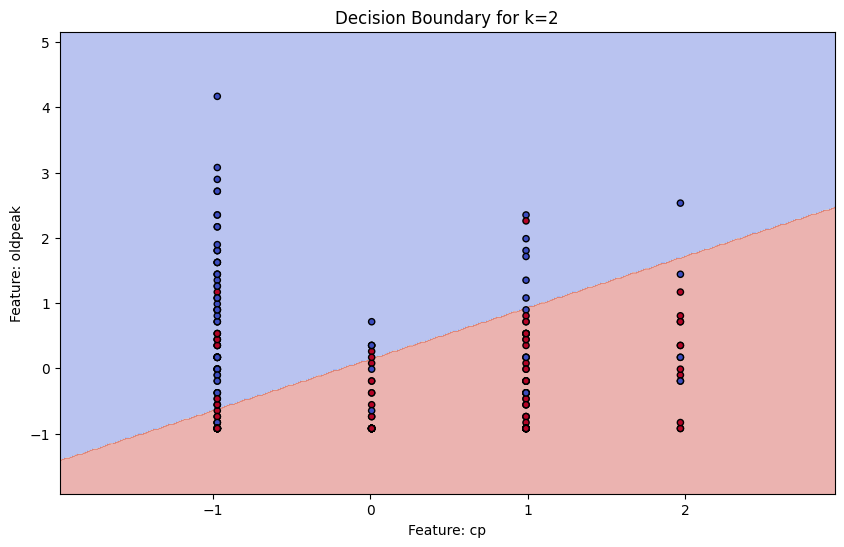

In [11]:
if len(selected_features_ordered) >= 2:
    features_k2 = selected_features_ordered[:2]
    print(f"\n--- Part (c) ---")
    print(f"The two features chosen for k=2 are: {features_k2[0]} and {features_k2[1]}")
    
    # Get the data corresponding to these two features
    x_train_k2 = x_train_scaled_df[features_k2]
    
    # Fit the model for k=2
    model_k2 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
    model_k2.fit(x_train_k2, y_train)
    
    # Plot the decision boundary using the training data
    # 
    print("Plotting decision boundary for k=2...")
    plot_decision_boundary(x_train_k2, y_train, model_k2, features_k2)
else:
    print("\nCould not complete part (c) as less than 2 features were selected.")